# Etapa 1 - EDA e Baseline

Tech Challenge Fase 1 - Pipeline Preditivo de Churn

Dataset: [Telco Customer Churn - IBM](https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset), do Kaggle.

Este notebook roda no Google Colab. O ambiente local so e usado depois, pra carregar o modelo treinado.

O que entregamos aqui: a analise exploratoria dos dados, a definicao das metricas e um modelo baseline de Regressao Logistica.

## 0. Contexto

Uma operadora de telecom esta perdendo clientes rapido. A ideia e prever quais clientes tem risco de cancelar, pra que o time de retencao consiga agir antes (oferta, ligacao, desconto) em vez de so descobrir depois que o cliente ja foi embora.

E um problema de classificacao binaria com dados tabulares. Cada linha do dataset e um cliente.

## 1. Setup

Duas bibliotecas que o Colab nao traz por padrao:

- `kagglehub` pra baixar o dataset direto do Kaggle
- `openpyxl` porque este dataset e um `.xlsx`, e sem essa engine o pandas nao le Excel

In [24]:
pip install -q kagglehub openpyxl ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Reprodutibilidade (requisito do enunciado) ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")

print("pandas:", pd.__version__, "| numpy:", np.__version__)

pandas: 3.0.3 | numpy: 2.4.6


## 2. Credenciais do Kaggle

Pra baixar o dataset pela API do Kaggle precisamos de usuario e chave. Elas ficam nos Secrets do Colab (icone de chave na barra lateral), com os nomes `KAGGLE_USERNAME` e `KAGGLE_KEY`.

Os valores saem do `kaggle.json`, que voce baixa no Kaggle em Settings > API > Create New Token.

Nao da pra colar essas credenciais direto numa celula: o notebook vai pro GitHub e a chave vazaria junto.

In [3]:
import kagglehub

try:
    from google.colab import userdata

    os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
    os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")
    print("Credenciais carregadas dos Secrets do Colab.")
except Exception as err:  # secret ausente, sem permissão, ou fora do Colab
    print(f"Não consegui ler os Secrets ({type(err).__name__}). Usando login interativo.")
    kagglehub.login()

Não consegui ler os Secrets (ModuleNotFoundError). Usando login interativo.


## 3. Download do dataset

O `dataset_download` baixa e descompacta, devolvendo o caminho da pasta. Na segunda vez ele usa o cache da sessao.

Listamos os arquivos em vez de assumir o nome, pra nao quebrar se o autor do dataset renomear alguma coisa.

In [4]:
import os
import kagglehub 

KAGGLE_DATASET = "yeanzc/telco-customer-churn-ibm-dataset"

dataset_dir = kagglehub.dataset_download(KAGGLE_DATASET)
print("Dataset baixado em:", dataset_dir, "\n")

for root, _dirs, files in os.walk(dataset_dir):
    for name in sorted(files):
        size_kb = os.path.getsize(os.path.join(root, name)) / 1024
        print(f"  {name:<45} {size_kb:>9.1f} KB")

Dataset baixado em: C:\Users\pata\.cache\kagglehub\datasets\yeanzc\telco-customer-churn-ibm-dataset\versions\1 

  Telco_customer_churn.xlsx                        1336.2 KB


## 4. Leitura do arquivo

O leitor e escolhido pela extensao: `.xlsx` vai de `read_excel` e `.csv` de `read_csv`.

Nao forcamos os tipos de proposito. Queremos ver como o pandas interpreta cada coluna, porque e ai que aparecem os problemas (uma coluna de valor que vem como texto, por exemplo).

In [5]:
# candidatos = [
#    os.path.join(root, name)                                # ERRADO! "os_artista" não existe
#    for root, _dirs, files in os.walk(dataset_dir)          # ERRADO! os.xlsx não existe
#    for name in files
#    if name.lower().endswith((".xlsx", ".xls", ".csv"))     # endswith aceita TUPLA, não 3 args
#]
# Encontrar o arquivo (pode ser .xlsx ou .csv)
candidatos = []
for root, dirs, files in os.walk(dataset_dir):
    for name in files:
        if name.lower().endswith((".xlsx", ".xls", ".csv")):
            candidatos.append(os.path.join(root, name))

if not candidatos:
    raise FileNotFoundError(f"Nenhum .xlsx/.csv encontrado em {dataset_dir}")

# Excel primeiro; entre iguais, o maior arquivo
DATA_PATH = sorted(
    candidatos,
    key=lambda p: p.endswith(".xlsx"), reverse=True)[0]

print("Arquivo escolhido: {os.path.basename(DATA_PATH)}")

# Ler o arquivo
if DATA_PATH.lower().endswith((".xlsx", ".xls")):
    df_raw = pd.read_excel(DATA_PATH)
else:
    df_raw = pd.read_csv(DATA_PATH)

print(f"Linhas: {df_raw.shape[0]:,} | Colunas: {df_raw.shape[1]}")
df_raw.head()

Arquivo escolhido: {os.path.basename(DATA_PATH)}
Linhas: 7,043 | Colunas: 33


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## 5. Inspecao do schema

Antes de limpar qualquer coisa, vale olhar coluna por coluna: qual o tipo, quantos nulos, quantos valores diferentes e quais sao esses valores.

Isso ja resolve algumas duvidas de cara. Coluna com um unico valor nao ensina nada ao modelo. Coluna com quase um valor por linha e identificador. E coluna numerica que aparece como texto tem sujeira dentro.

In [6]:
def resumo_schema(df: pd.DataFrame, max_exemplos: int = 4) -> pd.DataFrame:
    """Raio-x do DataFrame: tipo, nulos, cardinalidade e amostra de valores."""
    linhas = []
    for col in df.columns:
        s = df[col]
        unicos = s.dropna().unique()
        exemplos = ", ".join(map(str, unicos[:max_exemplos]))
        if len(unicos) > max_exemplos:
            exemplos += ", ..."
        linhas.append({
            "coluna": col,
            "dtype": str(s.dtype),
            "nulos": int(s.isna().sum()),
            "n_unicos": int(s.nunique(dropna=True)),
            "exemplos": exemplos,
        })
    return pd.DataFrame(linhas)


print(f"shape: {df_raw.shape}\n")
print(resumo_schema(df_raw).to_string(index=False))

shape: (7043, 33)

           coluna   dtype  nulos  n_unicos                                                                                                           exemplos
       CustomerID     str      0      7043                                                                3668-QPYBK, 9237-HQITU, 9305-CDSKC, 7892-POOKP, ...
            Count   int64      0         1                                                                                                                  1
          Country     str      0         1                                                                                                      United States
            State     str      0         1                                                                                                         California
             City     str      0      1129                                                          Los Angeles, Beverly Hills, Huntington Park, Lynwood, ...
         Zip Code   int64      0 

## 6. Limpeza

Tres coisas acontecem aqui: padronizar os nomes das colunas pra `snake_case`, criar a coluna alvo `churn` com 0 e 1, e tirar do dataset o que nao pode ser usado como feature.

In [7]:
import re


def normalizar(nome: str) -> str:
    """'Tenure Months' -> 'tenure_months' | 'Lat Long' -> 'lat_long'"""
    return re.sub(r"[^0-9a-zA-Z]+", "_", str(nome)).strip("_").lower()


# Nomes grudados (sem espaço) que a normalização sozinha não separa
ALIASES = {
    "customerid": "customer_id",
    "seniorcitizen": "senior_citizen",
    "tenure": "tenure_months",
    "monthlycharges": "monthly_charges",
    "totalcharges": "total_charges",
    "churnvalue": "churn_value",
    "churnlabel": "churn_label",
}

df = df_raw.copy()
df.columns = [ALIASES.get(normalizar(c), normalizar(c)) for c in df.columns]
print(list(df.columns))

# tipos das colunas
print(df.dtypes)

['customer_id', 'count', 'country', 'state', 'city', 'zip_code', 'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn_label', 'churn_value', 'churn_score', 'cltv', 'churn_reason']
customer_id              str
count                  int64
country                  str
state                    str
city                     str
zip_code               int64
lat_long                 str
latitude             float64
longitude            float64
gender                   str
senior_citizen           str
partner                  str
dependents               str
tenure_months          int64
phone_service            str
multiple_lines           str
internet_service         str
online_security

In [8]:
TARGET = "churn"

if "churn_value" in df.columns:
    df[TARGET] = df["churn_value"].astype(int)
elif "churn_label" in df.columns:
    df[TARGET] = (df["churn_label"].astype(str).str.strip().str.lower() == "yes").astype(int)
else:
    raise KeyError(f"Nenhuma coluna de churn encontrada em: {list(df.columns)}")

print(df[TARGET].value_counts())

churn
0    5174
1    1869
Name: count, dtype: int64


### 6.1 Vazamento de dados

Esta versao do dataset traz colunas que so existem depois que o cliente cancelou:

- `churn_label` e `churn_value` sao o proprio alvo
- `churn_score` e um score de churn que a IBM ja calculou
- `churn_reason` e o motivo do cancelamento, preenchido so pra quem cancelou
- `cltv` e o valor de tempo de vida, calculado com informacao futura

Se qualquer uma delas ficar no X, o modelo acerta quase tudo no teste e nao funciona em producao, porque la, pra um cliente ativo, essas colunas estao vazias. O resultado bom demais e o sinal de que algo esta errado.

Tambem tiramos os identificadores e a geografia. O `customer_id` e unico por linha, `country` e `state` tem um valor so, e `city` e `zip_code` tem centenas de categorias que nao generalizam.

In [9]:
VAZAMENTO = ["churn_label", "churn_value", "churn_score", "churn_reason", "cltv"]
IDS_E_GEO = [
    "customer_id", "count", "country", "state",
    "city", "zip_code", "lat_long", "latitude", "longitude",
]

# total_charges vem como texto: clientes com tenure 0 têm célula em branco
if "total_charges" in df.columns:
    df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")
    print(f"total_charges sem valor numérico: {df['total_charges'].isna().sum()}")
    df["total_charges"] = df["total_charges"].fillna(0)

descartar = [c for c in VAZAMENTO + IDS_E_GEO if c in df.columns]
df_clean = df.drop(columns=descartar)

# Rede de segurança: pega o que escapou da lista manual
constantes = [c for c in df_clean.columns if df_clean[c].nunique(dropna=False) <= 1]
alta_card = [
    c for c in df_clean.select_dtypes(include="object").columns
    if df_clean[c].nunique() > 30
]
df_clean = df_clean.drop(columns=constantes + alta_card)

print("Descartadas (lista)              :", descartar)
print("Descartadas (constantes)         :", constantes)
print("Descartadas (alta cardinalidade) :", alta_card)
print("\nShape final:", df_clean.shape)
df_clean.head()

total_charges sem valor numérico: 11


Descartadas (lista)              : ['churn_label', 'churn_value', 'churn_score', 'churn_reason', 'cltv', 'customer_id', 'count', 'country', 'state', 'city', 'zip_code', 'lat_long', 'latitude', 'longitude']
Descartadas (constantes)         : []
Descartadas (alta cardinalidade) : []

Shape final: (7043, 20)


C:\Users\pata\AppData\Local\Temp\ipykernel_41384\1583554254.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  c for c in df_clean.select_dtypes(include="object").columns


,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [10]:
NUMERICAS = [c for c in ["tenure_months", "monthly_charges", "total_charges"] if c in df_clean.columns]
CATEGORICAS = [c for c in df_clean.columns if c not in NUMERICAS + [TARGET]]

# senior_citizen pode vir como 0/1 ou Yes/No: tratamos como categoria nos dois casos
df_clean[CATEGORICAS] = df_clean[CATEGORICAS].astype(str)

print(f"{len(NUMERICAS)} numéricas : {NUMERICAS}")
print(f"{len(CATEGORICAS)} categóricas: {CATEGORICAS}")
assert df_clean.isna().sum().sum() == 0, "Ainda há nulos no dataset limpo"

3 numéricas : ['tenure_months', 'monthly_charges', 'total_charges']
16 categóricas: ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method']


## 7. Analise exploratoria

Aqui olhamos o volume dos dados, o balanceamento do alvo e como as principais variaveis se relacionam com o churn.

Ficou: 73.5%  |  Cancelou: 26.5%


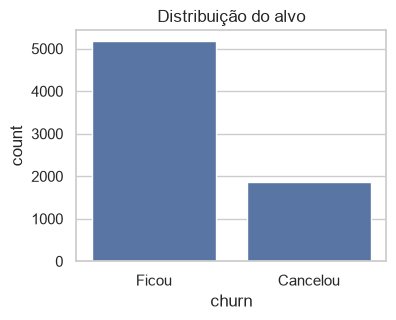

In [11]:
dist = df_clean[TARGET].value_counts(normalize=True).mul(100).round(1)
print(f"Ficou: {dist.get(0)}%  |  Cancelou: {dist.get(1)}%")

plt.figure(figsize=(4, 3))
sns.countplot(x=df_clean[TARGET])
plt.title("Distribuição do alvo")
plt.xticks([0, 1], ["Ficou", "Cancelou"])
plt.show()

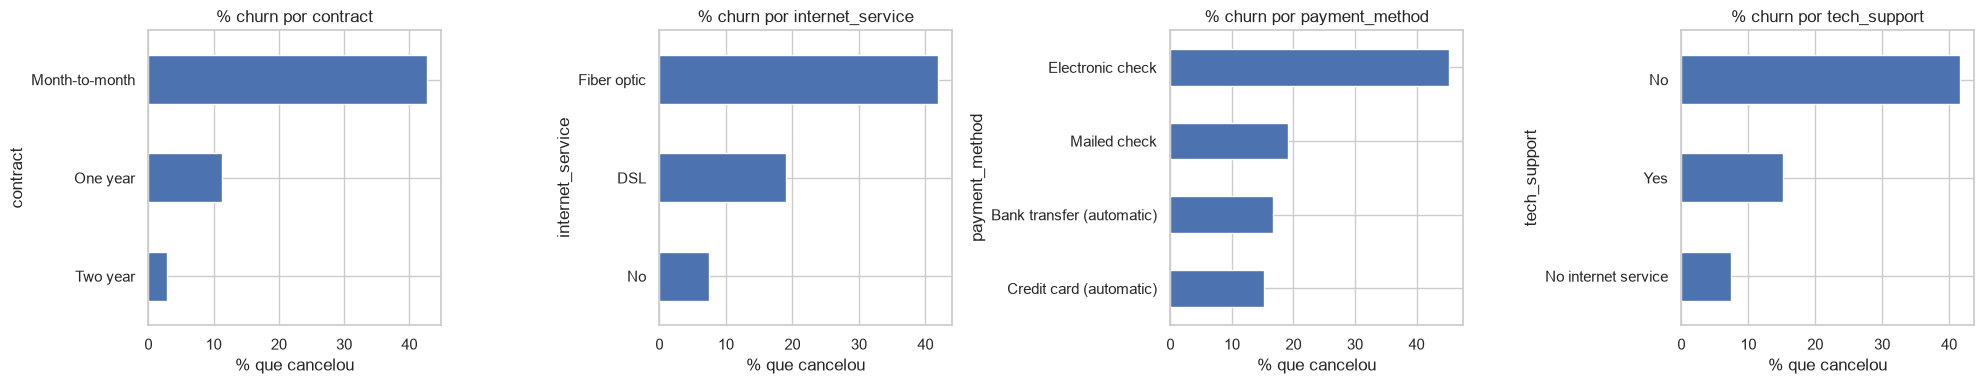

In [12]:
# Taxa de churn por categoria: onde o cancelamento se concentra
destaques = [c for c in ["contract", "internet_service", "payment_method", "tech_support"] if c in CATEGORICAS]

fig, axes = plt.subplots(1, len(destaques), figsize=(5 * len(destaques), 4))
for ax, col in zip(np.atleast_1d(axes), destaques):
    (df_clean.groupby(col)[TARGET].mean().sort_values() * 100).plot(kind="barh", ax=ax)
    ax.set_title(f"% churn por {col}")
    ax.set_xlabel("% que cancelou")
plt.tight_layout()
plt.show()

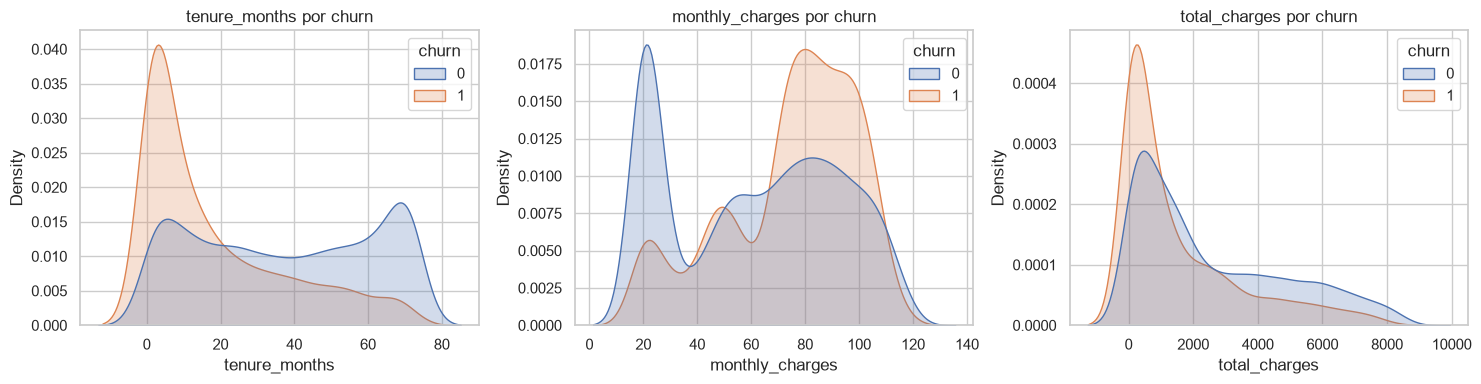

,tenure_months,monthly_charges,total_charges
churn,,,
0,37.57,61.27,2549.91
1,17.98,74.44,1531.80


In [13]:
fig, axes = plt.subplots(1, len(NUMERICAS), figsize=(5 * len(NUMERICAS), 4))
for ax, col in zip(np.atleast_1d(axes), NUMERICAS):
    sns.kdeplot(data=df_clean, x=col, hue=TARGET, fill=True, common_norm=False, ax=ax)
    ax.set_title(f"{col} por churn")
plt.tight_layout()
plt.show()

df_clean.groupby(TARGET)[NUMERICAS].mean().round(2)

**Observações da EDA**

- **Volume:** 7.043 clientes e 33 colunas no arquivo original. Depois da limpeza sobraram 19 features + o alvo.
- **Qualidade:** o dataset é bem completo. O único problema foi `total_charges`, que veio como texto porque 11 clientes estão em branco — são justamente os que têm `tenure_months = 0`, ou seja, entraram e ainda não foram cobrados. Preenchemos com 0.
- **Balanceamento:** 73,5% ficaram e 26,5% cancelaram. As classes são desbalanceadas, e é por isso que não usamos acurácia como métrica (ver seção 8).
- **Contrato é o fator mais forte:** quem tem contrato mês a mês cancela muito mais do que quem tem contrato de 1 ou 2 anos. Faz sentido, porque sem fidelidade sair não custa nada.
- **Tempo de casa:** quem cancela tem em média 18 meses de contrato, contra 38 meses de quem fica. O risco está concentrado nos clientes novos.
- **Valor da mensalidade:** quem cancela paga em média 74,44 por mês, contra 61,27 de quem fica. Cliente novo pagando caro é o perfil de maior risco.
- **Fibra óptica** aparece com taxa de cancelamento bem acima do DSL, o que combina com a mensalidade mais alta.

## 8. Metricas

Escolhemos a metrica antes de treinar. Se deixarmos pra depois, a tentacao e escolher justamente a que deu o numero mais bonito.

Acuracia nao serve aqui. Como so 26,5% dos clientes cancelam, um modelo que responde "ninguem vai cancelar" pra todo mundo ja acerta 73,5% e nao ajuda em nada.

Entao usamos:

- F1 da classe churn como metrica tecnica, porque equilibra precisao e recall na classe minoritaria, que e a que interessa
- AUC-ROC como metrica secundaria, porque mede se o modelo consegue ordenar os clientes por risco, independente do limiar escolhido
- Recall da classe churn como metrica de negocio

O recall e a metrica de negocio porque os custos sao assimetricos. Deixar passar um cliente que ia cancelar custa o cliente inteiro. Ligar pra alguem que nao ia cancelar custa uma ligacao ou um desconto. Entao e melhor errar pro lado de avisar demais.

## 9. Separacao treino e teste

O `stratify=y` mantem a mesma proporcao de churn nos dois conjuntos. Sem ele, o sorteio pode deixar o teste com poucos casos positivos e a avaliacao fica distorcida.

O `random_state=SEED` faz o sorteio ser sempre o mesmo, que e o requisito de reprodutibilidade do enunciado.

In [14]:
from sklearn.model_selection import train_test_split

X = df_clean[NUMERICAS + CATEGORICAS]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Treino: {X_train.shape} | churn = {y_train.mean():.1%}")
print(f"Teste : {X_test.shape} | churn = {y_test.mean():.1%}")

Treino: (5634, 19) | churn = 26.5%
Teste : (1409, 19) | churn = 26.5%


## 10. Pre-processamento

O `ColumnTransformer` aplica um tratamento diferente pra cada tipo de coluna.

Nas numericas usamos `StandardScaler`, que coloca tudo na mesma escala. Sem isso, `total_charges`, que chega na casa dos milhares, pesaria muito mais que `tenure_months`, que vai ate uns 70. Modelos lineares e redes neurais sao sensiveis a isso.

Nas categoricas usamos `OneHotEncoder`, que cria uma coluna binaria por categoria. O `handle_unknown="ignore"` importa pra API: se chegar uma categoria que o modelo nunca viu, ela vira zeros em vez de derrubar a requisicao com erro.

Juntar o pre-processamento e o classificador num `Pipeline` unico e o que garante que o treino e a API facam exatamente a mesma transformacao, ja que os dois vao salvos no mesmo arquivo.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERICAS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAS),
    ]
)

## 11. Baseline com Regressao Logistica

O baseline nao precisa ser o melhor modelo. Ele serve de regua.

Na Etapa 2, quando o Random Forest der algum numero, so da pra dizer se ele foi bem comparando com este aqui. Se a diferenca for pequena, nao compensa a complexidade a mais.

In [16]:
from sklearn.linear_model import LogisticRegression

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=SEED,
    class_weight='balanced'  # ESSENCIAL para dados desbalanceados!
    )),
])

baseline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## 12. Avaliacao

In [17]:
from sklearn.metrics import classification_report, f1_score, recall_score, roc_auc_score

y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Ficou", "Cancelou"]))
print(f"F1 (churn)     : {f1_score(y_test, y_pred):.3f}   <- métrica técnica")
print(f"Recall (churn) : {recall_score(y_test, y_pred):.3f}   <- métrica de negócio")
print(f"AUC-ROC        : {roc_auc_score(y_test, y_proba):.3f}")

              precision    recall  f1-score   support

       Ficou       0.90      0.73      0.81      1035
    Cancelou       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

F1 (churn)     : 0.617   <- métrica técnica
Recall (churn) : 0.781   <- métrica de negócio
AUC-ROC        : 0.849


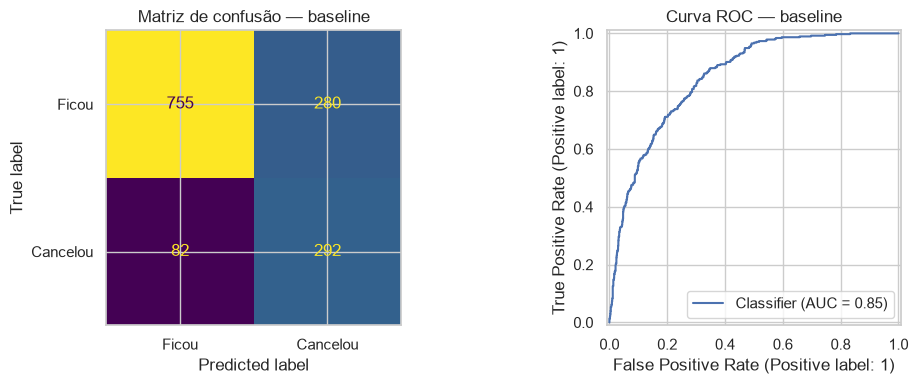

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Ficou", "Cancelou"], ax=axes[0], colorbar=False
)
axes[0].set_title("Matriz de confusão — baseline")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title("Curva ROC — baseline")
plt.tight_layout()
plt.show()

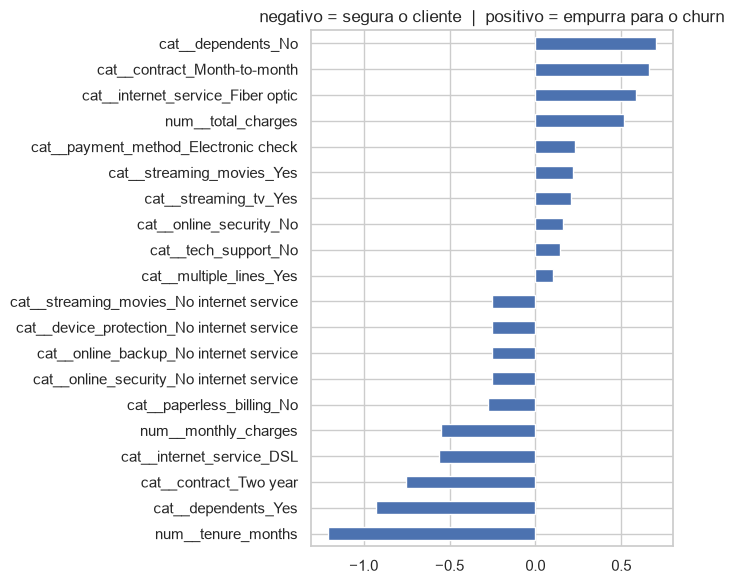

In [19]:
# O que mais empurra para o churn (coeficientes) — material para o Model Card
nomes = baseline.named_steps["preprocessor"].get_feature_names_out()
coefs = pd.Series(baseline.named_steps["classifier"].coef_[0], index=nomes).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
pd.concat([coefs.head(10), coefs.tail(10)]).plot(kind="barh", ax=ax)
ax.set_title("negativo = segura o cliente  |  positivo = empurra para o churn")
plt.tight_layout()
plt.show()

### 12.1 Testando com class_weight balanced

Como a metrica de negocio e o recall, vale medir tambem a versao que penaliza mais o erro na classe minoritaria.

O esperado e que o recall suba e a precisao caia um pouco, que e a troca que faz sentido pro negocio. Guardamos o resultado pra usar na decisao da Etapa 2.

In [20]:
baseline_bal = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
]).fit(X_train, y_train)

pred_bal = baseline_bal.predict(X_test)
proba_bal = baseline_bal.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "LogReg": [f1_score(y_test, y_pred), recall_score(y_test, y_pred), roc_auc_score(y_test, y_proba)],
    "LogReg balanced": [f1_score(y_test, pred_bal), recall_score(y_test, pred_bal), roc_auc_score(y_test, proba_bal)],
}, index=["F1 (churn)", "Recall (churn)", "AUC-ROC"]).round(3)

,LogReg,LogReg balanced
F1 (churn),0.617,0.617
Recall (churn),0.781,0.781
AUC-ROC,0.849,0.849


## 13. Salvando o modelo

O `joblib.dump` grava o pipeline inteiro num arquivo, com o pre-processamento e o classificador juntos. Depois e so carregar com `joblib.load` e usar, sem treinar de novo.

Como estamos no Colab, salvamos na sessao e baixamos pelo navegador. O arquivo vai pra pasta `models/` do projeto.

In [21]:
import joblib
import sklearn

ARQUIVO = "baseline_logistic_regression.joblib"
joblib.dump(baseline, ARQUIVO)
print(f"Salvo: {ARQUIVO} | scikit-learn {sklearn.__version__}")

try:
    from google.colab import files

    files.download(ARQUIVO)
except ImportError:
    print("Fora do Colab — o arquivo ficou na pasta atual.")

Salvo: baseline_logistic_regression.joblib | scikit-learn 1.8.0
Fora do Colab — o arquivo ficou na pasta atual.



### SALVAR VARIÁVEIS PARA A FASE 2

 
Esta célula salva todas as variáveis criadas na Fase 1
para que a Fase 2 possa carregá-las sem precisar 
rodar a Fase 1 inteira novamente.


In [22]:
import joblib
import os

print("=" * 50)
print("SALVANDO VARIÁVEIS PARA A FASE 2")
print("=" * 50)

# Criar pasta models/ se não existir
os.makedirs('models', exist_ok=True)

# 1. Salvar o DataFrame limpo
df_clean.to_pickle('df_clean.pkl')
print("df_clean.pkl salvo")

# 2. Salvar o pré-processador
joblib.dump(preprocessor, 'preprocessor.joblib')
print("preprocessor.joblib salvo")

# 3. Salvar o modelo baseline
joblib.dump(baseline_bal, 'models/baseline_logistic_regression.joblib')
print("baseline_logistic_regression.joblib salvo")

# 4. Salvar as listas de colunas
joblib.dump({
    'NUMERICAS': NUMERICAS,
    'CATEGORICAS': CATEGORICAS,
    'TARGET': TARGET,
    'SEED': SEED
}, 'colunas.joblib')
print("colunas.joblib salvo")

# 5. Salvar as métricas do baseline
import json
metricas = {
    'f1_score': float(f1_score(y_test, baseline_bal.predict(X_test))),
    'recall': float(recall_score(y_test, baseline_bal.predict(X_test))),
    'auc_roc': float(roc_auc_score(y_test, baseline_bal.predict_proba(X_test)[:, 1]))
}

with open('models/baseline_metrics.json', 'w') as f:
    json.dump(metricas, f, indent=2)
print("baseline_metrics.json salvo")

print("\n" + "=" * 50)
print("TODAS AS VARIÁVEIS SALVAS COM SUCESSO!")
print("=" * 50)
print("\nArquivos criados:")
print("   df_clean.pkl")
print("   preprocessor.joblib")
print("   colunas.joblib")
print("   models/")
print("      baseline_logistic_regression.joblib")
print("      baseline_metrics.json")
print("\n Agora a Fase 2 pode carregar tudo rapidamente!")

SALVANDO VARIÁVEIS PARA A FASE 2
df_clean.pkl salvo
preprocessor.joblib salvo
baseline_logistic_regression.joblib salvo
colunas.joblib salvo
baseline_metrics.json salvo

TODAS AS VARIÁVEIS SALVAS COM SUCESSO!

Arquivos criados:
   df_clean.pkl
   preprocessor.joblib
   colunas.joblib
   models/
      baseline_logistic_regression.joblib
      baseline_metrics.json

 Agora a Fase 2 pode carregar tudo rapidamente!
